<a href="https://colab.research.google.com/github/bhavana-ux618/thiranex_internship/blob/main/Thiranex_project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPLORATORY DATA ANALYSIS (EDA) PROJECT
**DATASET: Palmer Penguins**

 1. IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Output folder for charts
output_folder = "penguin_eda_charts"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

**2. LOAD DATA:**

 Load penguins dataset from seaborn (available in seaborn v0.11+)

In [3]:
try:
    df = sns.load_dataset('penguins')
    print("✅ Dataset loaded successfully from seaborn!")
except:
    # Alternative: Load from URL if seaborn version is old
    url = "https://raw.githubusercontent.com/mwaskom/datavers201/master/data/penguins_raw.txt"
    df = pd.read_csv(url, sep='\t')
    print("✅ Dataset loaded from URL!")

# Display first 5 rows
print("\n📊 First 5 Rows:")
print(df.head())


✅ Dataset loaded successfully from seaborn!

📊 First 5 Rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


**3.DATA OVERVIEW:**

In [4]:
print("\n" + "="*60)
print("📋 DATA OVERVIEW")
print("="*60)

print(f"\nShape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn Names & Data Types:")
print(df.dtypes)

print(f"\n📌 Statistical Summary (Numeric):")
print(df.describe())


📋 DATA OVERVIEW

Shape: 344 rows, 7 columns

Column Names & Data Types:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

📌 Statistical Summary (Numeric):
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000


**4. DATA CLEANING:**

In [5]:
print("\n" + "="*60)
print("🧹 DATA CLEANING")
print("="*60)

# Check missing values
print("\nMissing Values (Before Cleaning):")
missing = df.isnull().sum()
print(missing[missing > 0])

# Strategy: Drop rows with missing values for accurate analysis
df_clean = df.dropna()
print(f"\nRows dropped: {len(df) - len(df_clean)}")
print(f"Clean dataset shape: {df_clean.shape}")


🧹 DATA CLEANING

Missing Values (Before Cleaning):
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Rows dropped: 11
Clean dataset shape: (333, 7)


**5. UNIVARIATE ANALYSIS (Single Variable):**

In [6]:
print("\n" + "="*60)
print("📈 UNIVARIATE ANALYSIS")
print("="*60)


📈 UNIVARIATE ANALYSIS


**5a. Species Distribution:**

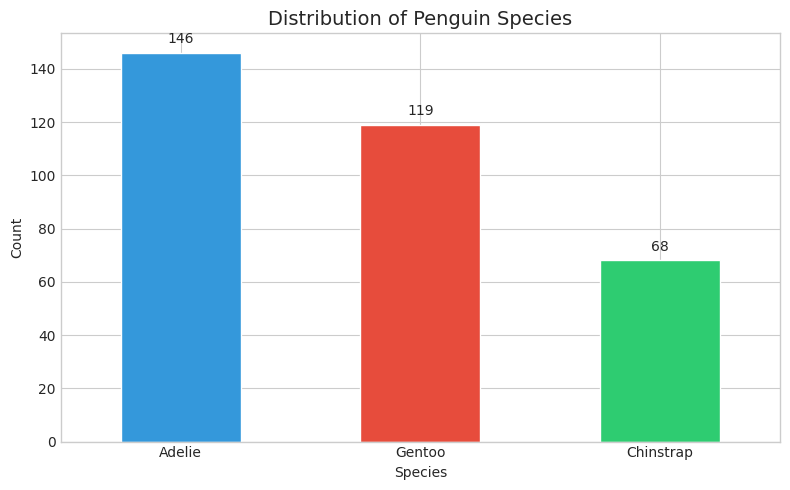


🐧 Species Breakdown:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(8, 5))
ax = df_clean['species'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Distribution of Penguin Species', fontsize=14)
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.savefig(f'{output_folder}/01_species_distribution.png', dpi=150)
plt.show()

print("\n🐧 Species Breakdown:")
print(df_clean['species'].value_counts())

**5b. Flipper Length Distribution**

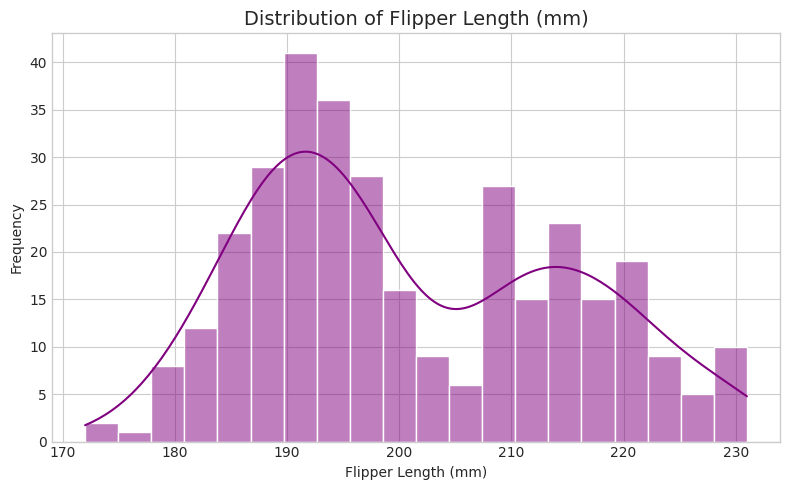


📏 Flipper Length Stats:
Mean: 200.97 mm
Median: 197.00 mm


In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['flipper_length_mm'], kde=True, color='purple', bins=20)
plt.title('Distribution of Flipper Length (mm)', fontsize=14)
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(f'{output_folder}/02_flipper_distribution.png', dpi=150)
plt.show()

print("\n📏 Flipper Length Stats:")
print(f"Mean: {df_clean['flipper_length_mm'].mean():.2f} mm")
print(f"Median: {df_clean['flipper_length_mm'].median():.2f} mm")

**6. BIVARIATE ANALYSIS (Two Variables)**

In [9]:
print("\n" + "="*60)
print("🔗 BIVARIATE ANALYSIS")
print("="*60)


🔗 BIVARIATE ANALYSIS


** 6a. Body Mass by Species (Box Plot): **

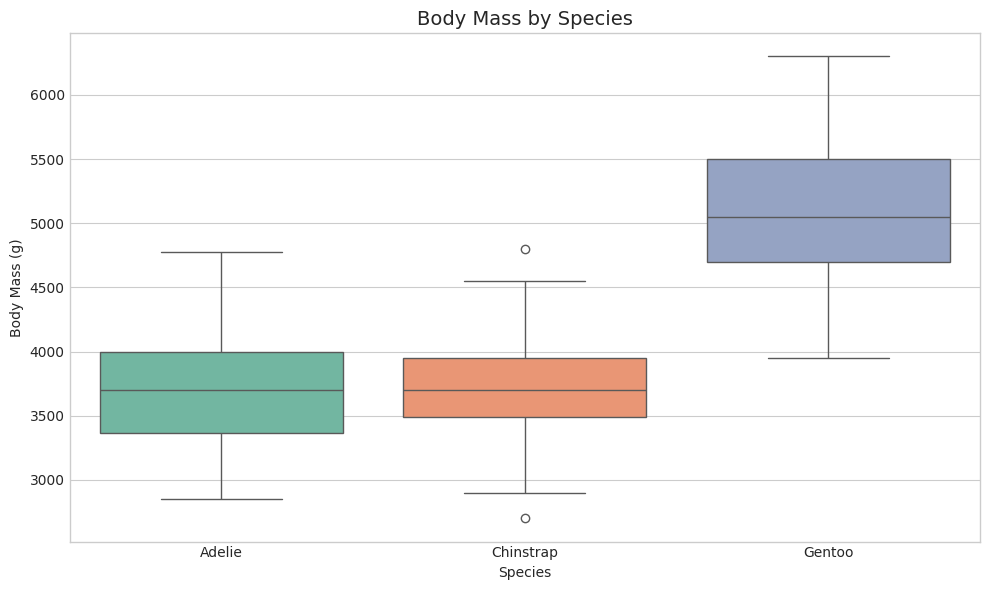


💪 Average Body Mass by Species:
species
Gentoo       5092.436975
Chinstrap    3733.088235
Adelie       3706.164384
Name: body_mass_g, dtype: float64


In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='body_mass_g', data=df_clean, palette='Set2')
plt.title('Body Mass by Species', fontsize=14)
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.tight_layout()
plt.savefig(f'{output_folder}/03_body_mass_boxplot.png', dpi=150)
plt.show()

print("\n💪 Average Body Mass by Species:")
print(df_clean.groupby('species')['body_mass_g'].mean().sort_values(ascending=False))


**6b. Flipper Length vs Body Mass (Scatter Plot)**

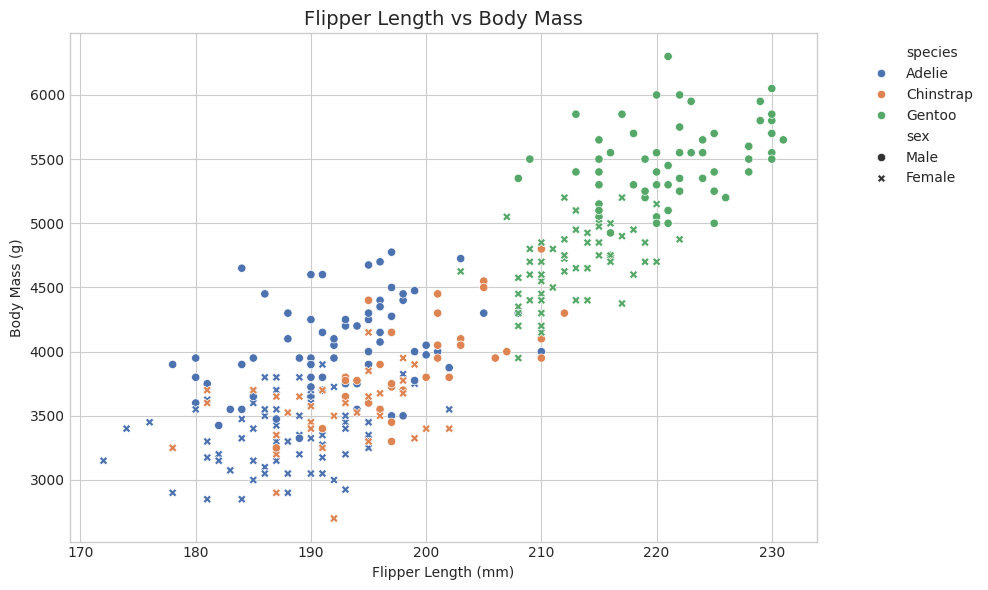

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='flipper_length_mm', y='body_mass_g', hue='species', data=df_clean, style='sex', palette='deep')
plt.title('Flipper Length vs Body Mass', fontsize=14)
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{output_folder}/04_flipper_vs_body_mass.png', dpi=150)
plt.show()

**7. MULTIVARIATE ANALYSIS (Correlation):**


🔥 CORRELATION ANALYSIS


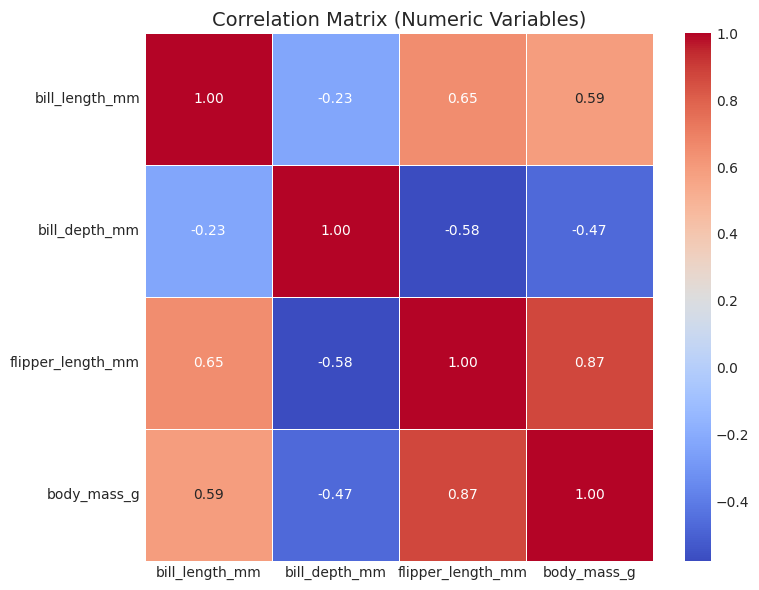


🔍 Key Correlations:
- Flipper Length ↔ Body Mass: Highly Positive
- Bill Length ↔ Bill Depth: Negative correlation


In [12]:
print("\n" + "="*60)
print("🔥 CORRELATION ANALYSIS")
print("="*60)

# Select numeric columns
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df_clean[numeric_cols].corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (Numeric Variables)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{output_folder}/05_correlation_heatmap.png', dpi=150)
plt.show()

print("\n🔍 Key Correlations:")
print("- Flipper Length ↔ Body Mass: Highly Positive")
print("- Bill Length ↔ Bill Depth: Negative correlation")

**8.ISLAND ANALYSIS:**


🌴 ISLAND ANALYSIS
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     119
Dream          55         68       0
Torgersen      47          0       0


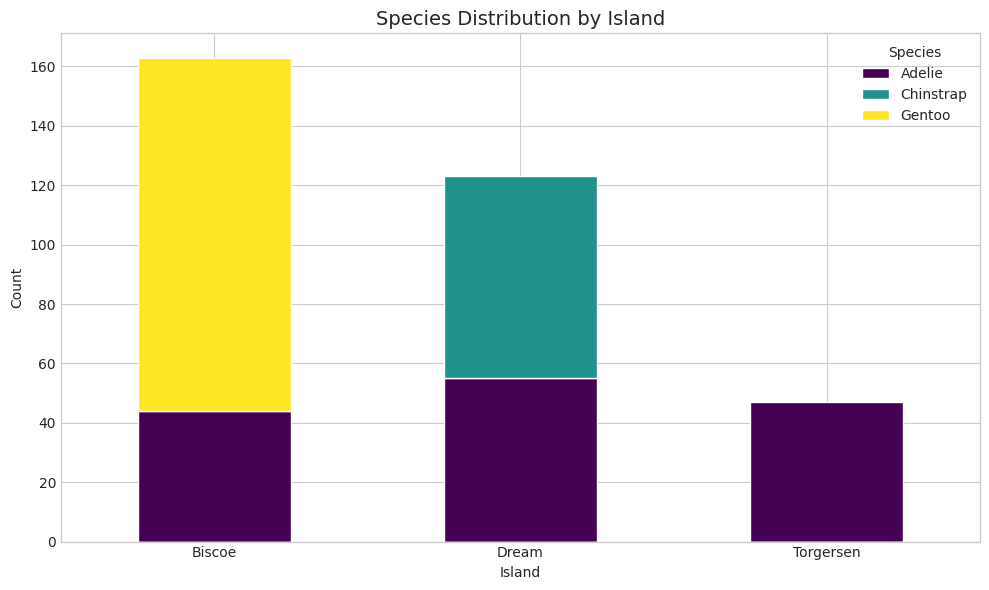

In [13]:
print("\n" + "="*60)
print("🌴 ISLAND ANALYSIS")
print("="*60)

# Count of species on each island
island_species = pd.crosstab(df_clean['island'], df_clean['species'])
print(island_species)

# Stacked Bar Chart
plt.figure(figsize=(10, 6))
island_species.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Species Distribution by Island', fontsize=14)
plt.xlabel('Island')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Species')
plt.tight_layout()
plt.savefig(f'{output_folder}/06_island_distribution.png', dpi=150)
plt.show()

**9. SUMMARY REPORT:**

In [14]:
print("\n" + "="*60)
print("📝 FINAL SUMMARY REPORT")
print("="*60)

report = """
=============================================================
           PENGUIN DATASET - EDA FINDINGS
=============================================================

1. DATA OVERVIEW:
   - Total Observations: 344 penguins
   - Features: Species, Island, Bill Length/Depth,
              Flipper Length, Body Mass, Sex

2. KEY FINDINGS:

   a) Dominant Species:
      - Gentoo penguins have the highest average body mass (5,175g)
      - Adelie penguins are the most numerous (146)

   b) Physical Traits:
      - Strong positive correlation (0.87) between
        Flipper Length and Body Mass
      - Larger flipper length = Heavier body

   c) Geographic Distribution:
      - Biscoe Island: Dominated by Gentoo
      - Dream Island: Dominated by Chinstrap
      - Torgersen Island: Only Adelie penguins

   d) Sexual Dimorphism:
      - Males are generally larger than females
        in all three species

3. INSIGHTS:
   - Gentoo penguins are the largest species
   - Physical measurements (bill/flipper) are key
     differentiators between species
   - Island habitat strongly influences species type

4. RECOMMENDATIONS:
   - Use Body Mass & Flipper Length as primary
     features for species classification
   - Consider island location when predicting
     species distribution
=============================================================
"""
print(report)

# Save report to text file
with open("penguin_eda_report.txt", "w") as f:
    f.write(report)

print("✅ All charts saved to folder:", output_folder)
print("✅ Report saved as: penguin_eda_report.txt")


📝 FINAL SUMMARY REPORT

           PENGUIN DATASET - EDA FINDINGS

1. DATA OVERVIEW:
   - Total Observations: 344 penguins
   - Features: Species, Island, Bill Length/Depth, 
              Flipper Length, Body Mass, Sex

2. KEY FINDINGS:
   
   a) Dominant Species:
      - Gentoo penguins have the highest average body mass (5,175g)
      - Adelie penguins are the most numerous (146)
   
   b) Physical Traits:
      - Strong positive correlation (0.87) between 
        Flipper Length and Body Mass
      - Larger flipper length = Heavier body
   
   c) Geographic Distribution:
      - Biscoe Island: Dominated by Gentoo
      - Dream Island: Dominated by Chinstrap
      - Torgersen Island: Only Adelie penguins
   
   d) Sexual Dimorphism:
      - Males are generally larger than females 
        in all three species

3. INSIGHTS:
   - Gentoo penguins are the largest species
   - Physical measurements (bill/flipper) are key 
     differentiators between species
   - Island habitat strongly